# This file analyzes the cases stored in sweep_cases

In [1]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend, nice_ax_legend
import matplotlib.pyplot as plt
import numpy as np
import copy
clrs = Colors.colors()


from CustomSchemes.DumbTransport import flat_transport


def get_norm(x: np.ndarray, xref: np.ndarray, order: int = 2) -> float:
  """gets the norm with the given order (default 2)"""
  return (np.linalg.norm(x - xref, ord=order)/np.linalg.norm(x, ord=order))

def get_all_norms_prev(x: list[np.ndarray], **kwargs):
  """get norms using previous solution"""
  resids_x = []
  npg = 0
  solve_np = 100000*500 # number active particles in each iteration
  x_old = x[0]
  x = x[1:]
  while len(x) > 0:
    resids_x.append(get_norm(x=x[0], xref=x_old))
    x_old = x[0]
    x = x[1:]
  return resids_x

def get_all_norms(x: list[np.ndarray], ref: np.ndarray):
  """get norms using a known reference solution"""
  resids_x = []
  npg = 0
  solve_np=100000*500
  total_histories = []
  for idx, this in enumerate(x):
    resids_x.append(get_norm(this, ref))
    total_histories.append(npg)
    try:
      npg+=solve_np
    except:
      npg += 0
  return resids_x

def particles_from_npg(time: float, aa: Anderson, nactive: int):
  """gets cumulative particles from NPG variable"""
  # for anderson, the first x() soln is always the predictor, which requires no NPG to get
  assert isinstance(aa, Anderson), "aa is not type Anderson"
  npg = 0
  npgvec = aa._npg[time]
  assert npgvec is not None, "npg vec is None, "
  new = [npg]
  for this in npgvec:
    new.append(new[-1] + this*nactive)

  assert len(new) == len(aa.x[time])
  return new

def particles_from_steps(time: float, aa: Anderson | SIE, nactive: int, npg: int):
  """used when you have a constant particles per step (not increasing hisstories withn more iterates)"""
  if isinstance(aa, Anderson):
    return _aa_particles_from_steps(time=time, aa=aa, nactive=nactive, npg=npg)
  elif isinstance(aa, SIE):
    return _sie_particles_from_steps(time=time, sie=aa, nactive=nactive, npg=npg)
  else:
    raise Exception("Not Anderson or SIE -- we dont know what to do!")

def _aa_particles_from_steps(time: float, aa: Anderson, nactive: int, npg: int):
  """aa uses x[0] as the predictor which means no particles are required"""
  return np.linspace(0,npg*nactive*(len(aa.x[time])-1), len(aa.x[time]))

def _sie_particles_from_steps(time: float, sie: SIE, nactive: int, npg: int):
  """sie uses x[0] as an actual solve, so we start at a nonzero number"""
  return np.linspace(npg*nactive,npg*nactive*(len(sie.x[time])), len(sie.x[time]))

def get_the_max(norms: list[np.ndarray]):
  """gets the max norm given a list of norm vectors"""
  the_max = copy.deepcopy(norms[0])
  for idx, _ in enumerate(the_max):
    for norm in norms:
      if norm[idx] > the_max[idx]:
        the_max[idx] = norm[idx]

  return the_max

def get_the_min(norms: list[np.ndarray]):
  """gets the max norm given a list of norm vectors"""
  the_max = copy.deepcopy(norms[0])
  for idx, _ in enumerate(the_max):
    for norm in norms:
      if norm[idx] < the_max[idx]:
        the_max[idx] = norm[idx]

  return the_max

def get_the_average(norms: list[np.ndarray]):
  """gets the average norm vs. iteration from a list of norm arrays"""
  the_max = np.zeros(len(norms[0]))
  for norm in norms:
    the_max += np.array(norm)
  the_max /= len(norms)
  return the_max

def get_aa_norm_average(order: int, factor: int, npg: int) -> tuple[list[int], np.ndarray[tuple[int], float]]:
  """gets the aa norm average across a number of simulations for a given:
  order and factor f"""
  norm_list = []
  for s in range(1,21):
    try:
      aa = Anderson().get_from_pkl(f'{folder}/aa{order}_f{factor}_s{s}_npg{npg}.pkl')
    except:
      continue
    parts = particles_from_npg(time=time, aa=aa, nactive=nactive) # getting particles from np
    norms = get_all_norms(x=aa.x[time], ref=flat_transport(16)) # norms against reference
    norm_list.append(norms)
  return parts, get_the_average(norm_list)

def get_sie_results_average(npg: int, niter: int, nactive: int, time: float | int):
  """gets the average of all 20x sie results for a given npg and niter case"""
  all_norms = []
  for s in range(1,21):
    try:
      sie = SIE().get_from_pkl(f'results/SIE_SWEEP_RESULTS/sie_s{s}_npg{npg}_i{niter}.pkl')
    except:
      continue
    parts = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)
    norms = get_all_norms(x=sie.x[time], ref=flat_transport(16))
    all_norms.append(norms)
  the_mean_norms = get_the_average(all_norms)
  return parts, the_mean_norms

def get_sie_results_all(npg: int, niter: int, nactive: int, time: float | int):
  """get all of the sie results norms

  Returns
  =======
  number of particles [1D array]

  a list of norms [list of np arrays]
  """
  all_norms = []
  for s in range(1,21):
    try:
      sie = SIE().get_from_pkl(f'results/SIE_SWEEP_RESULTS/sie_s{s}_npg{npg}_i{niter}.pkl')
    except:
      continue
    parts = particles_from_steps(time=time, aa=sie, nactive=nactive, npg=npg)
    norms = get_all_norms(x=sie.x[time], ref=flat_transport(16))
    all_norms.append(norms)
  return parts, all_norms

# Get the data from **sweep_cases/RESULTS** and plot it 

Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa2_f4.0_s10_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s3_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s5_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s7_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s12_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s14_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s16_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa3_f1.5_s17_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa4_f1.5_s14_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa4_f1.5_s15_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa5_f1.5_s9_npg10000.pkl
Skipping /scratch/fauljona/openmc_RM_SIE/sweep_

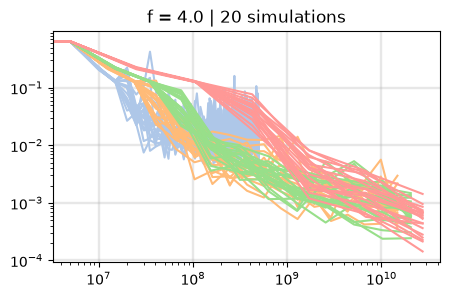

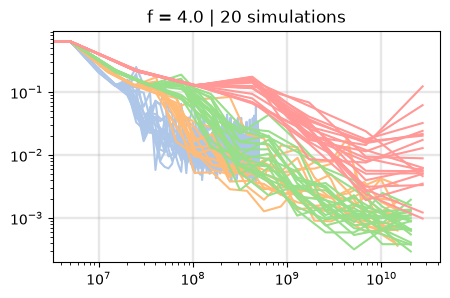

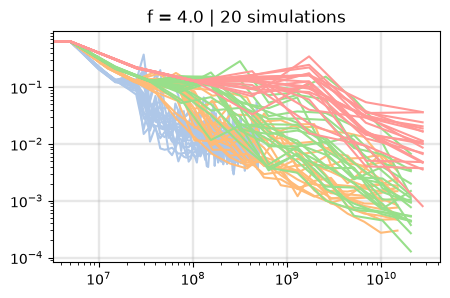

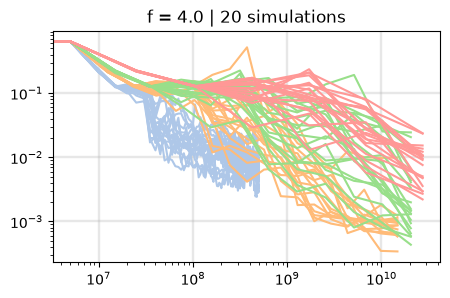

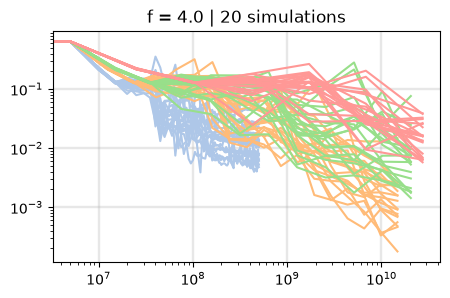

In [26]:
# Define
factors = [1, 1.5, 2.0, 4.0]
ms = [2,3,4,5,6]
npg = 10000
nactive=500
time = 325
d = {}


for m in ms:
  idx = -1
  d[m] = {}
  plt.figure(figsize=(5,3), dpi=100)
  for f in factors:
    idx += 1
    average = None

    count = 0
    for s in range(1,21):
      filename = f"/scratch/fauljona/openmc_RM_SIE/sweep_cases/RESULTS/aa{m}_f{f}_s{s}_npg{npg}.pkl"
      try:
        aa = Anderson().get_from_pkl(f'{filename}')
      except:
        print(f"Skipping {filename}")
        continue
      parts = particles_from_npg(time=time, aa=aa, nactive=nactive) # getting particles from np
      norms = get_all_norms(x=aa.x[time], ref=flat_transport(16)) # norms against reference
      if average is None:
        average = np.array(norms)
        count = 1
      else:
        average += norms
        count += 1
      plt.plot(parts,norms, '-', color=Colors.colors()[idx])
    plt.yscale('log')
    plt.xscale('log')
    nice_grid()
    plt.title(f"f = {f} | 20 simulations")
    d[m][f] = (parts, average/count)




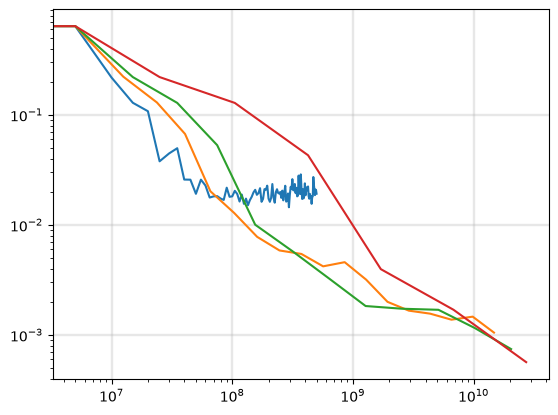

In [27]:
m = 2 # choose the m to use
for f in d[m].keys():
  parts, avg = d[m][f]
  plt.plot(parts, avg, label=f'{f}')
plt.yscale('log')
plt.xscale('log')
nice_grid()

In [18]:
d[m]

{4.0: ([0,
   5000000,
   25000000,
   105000000,
   425000000,
   1705000000,
   6825000000,
   27305000000],
  array([ 8.74096644, 12.80873157,  4.40383504,  2.56681407,  2.48738293,
          2.62614975,  0.45681039,  0.2562925 ]))}